<a href="https://colab.research.google.com/github/eileenwill4-ops/DSRP-project/blob/main/(DSRP__Project).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np

url = 'https://raw.githubusercontent.com/eileenwill4-ops/DSRP-project/refs/heads/main/zip_water_quality.csv'

df = pd.read_csv(url)

print(df.shape)
df.info()

(41344, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41344 entries, 0 to 41343
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   zip                       41344 non-null  int64  
 1   city                      41344 non-null  object 
 2   state                     41344 non-null  object 
 3   system_name               41344 non-null  object 
 4   pwsid                     41344 non-null  object 
 5   population                41344 non-null  float64
 6   water_source              41343 non-null  object 
 7   total_violations          41344 non-null  float64
 8   health_violations         41344 non-null  float64
 9   unresolved_violations     41344 non-null  float64
 10  contaminant_count         41344 non-null  int64  
 11  health_contaminant_names  11072 non-null  object 
 12  latitude                  41344 non-null  float64
 13  longitude                 41344 non-null  float64

In [11]:
df.shape

(41344, 15)

In [8]:
df.dtypes

,0
zip,int64
city,object
state,object
system_name,object
pwsid,object
population,float64
water_source,object
total_violations,float64
health_violations,float64
unresolved_violations,float64


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41344 entries, 0 to 41343
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   zip                       41344 non-null  int64  
 1   city                      41344 non-null  object 
 2   state                     41344 non-null  object 
 3   system_name               41344 non-null  object 
 4   pwsid                     41344 non-null  object 
 5   population                41344 non-null  float64
 6   water_source              41343 non-null  object 
 7   total_violations          41344 non-null  float64
 8   health_violations         41344 non-null  float64
 9   unresolved_violations     41344 non-null  float64
 10  contaminant_count         41344 non-null  int64  
 11  health_contaminant_names  11072 non-null  object 
 12  latitude                  41344 non-null  float64
 13  longitude                 41344 non-null  float64
 14  has_ac

In [24]:
df.describe(include='all')
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.describe(include='all')

,zip,city,state,system_name,pwsid,population,water_source,total_violations,health_violations,unresolved_violations,contaminant_count,health_contaminant_names,latitude,longitude,has_active_issues
count,41344.000000,41344,41344,41344,41344,4.134400e+04,41343,41344.000000,41344.000000,41344.000000,41344.000000,11072,41344.000000,41344.000000,35100
unique,NaN,18579,51,20921,16718,NaN,2,NaN,NaN,NaN,NaN,651,NaN,NaN,2
top,NaN,Washington,TX,New York City System,NY7003493,NaN,SW,NaN,NaN,NaN,NaN,Stage 2 DBP Rule,NaN,NaN,True
freq,NaN,300,2649,274,296,NaN,21447,NaN,NaN,NaN,NaN,2669,NaN,NaN,19132
mean,49849.686847,NaN,NaN,NaN,NaN,2.301964e+05,NaN,6.662539,1.075126,2.474023,0.427099,NaN,38.592323,-91.154586,NaN
std,27818.005406,NaN,NaN,NaN,NaN,8.235376e+05,NaN,18.668761,3.556683,9.080675,0.896748,NaN,5.236934,15.345359,NaN
min,1001.000000,NaN,NaN,NaN,NaN,0.000000e+00,NaN,0.000000,0.000000,0.000000,0.000000,NaN,19.066800,-176.634000,NaN
25%,26447.750000,NaN,NaN,NaN,NaN,1.332000e+03,NaN,0.000000,0.000000,0.000000,0.000000,NaN,35.044300,-97.327700,NaN
50%,49049.000000,NaN,NaN,NaN,NaN,7.809500e+03,NaN,1.000000,0.000000,0.000000,0.000000,NaN,39.144250,-87.991750,NaN
75%,73103.250000,NaN,NaN,NaN,NaN,9.534500e+04,NaN,6.000000,1.000000,2.000000,1.000000,NaN,41.888200,-80.143400,NaN


In [25]:
print(df.duplicated().sum())
df = df.drop_duplicates()
#(-check complete, zero duplicates detected)

0


In [48]:
#convert text numbers to numeric, coercing unparseable text errors into NaN
df['population'] = pd.to_numeric(df['population'], errors='coerce')
df.describe(include='all')

#(-uneccessary:nothing changed)


,zip,city,state,system_name,pwsid,population,water_source,total_violations,health_violations,unresolved_violations,contaminant_count,health_contaminant_names,latitude,longitude,has_active_issues
count,41344.000000,41344,41344,41344,41344,4.134400e+04,41344,41344.000000,41344.000000,41344.000000,41344.000000,41344,41344.000000,41344.000000,41344
unique,NaN,18579,51,20921,16718,NaN,2,NaN,NaN,NaN,NaN,652,NaN,NaN,2
top,NaN,Washington,TX,New York City System,NY7003493,NaN,SW,NaN,NaN,NaN,NaN,No Health Contaminants,NaN,NaN,True
freq,NaN,300,2649,274,296,NaN,21448,NaN,NaN,NaN,NaN,30272,NaN,NaN,25376
mean,49849.686847,NaN,NaN,NaN,NaN,2.301964e+05,NaN,6.662539,1.075126,2.474023,0.427099,NaN,38.592323,-91.154586,NaN
std,27818.005406,NaN,NaN,NaN,NaN,8.235376e+05,NaN,18.668761,3.556683,9.080675,0.896748,NaN,5.236934,15.345359,NaN
min,1001.000000,NaN,NaN,NaN,NaN,0.000000e+00,NaN,0.000000,0.000000,0.000000,0.000000,NaN,19.066800,-176.634000,NaN
25%,26447.750000,NaN,NaN,NaN,NaN,1.332000e+03,NaN,0.000000,0.000000,0.000000,0.000000,NaN,35.044300,-97.327700,NaN
50%,49049.000000,NaN,NaN,NaN,NaN,7.809500e+03,NaN,1.000000,0.000000,0.000000,0.000000,NaN,39.144250,-87.991750,NaN
75%,73103.250000,NaN,NaN,NaN,NaN,9.534500e+04,NaN,6.000000,1.000000,2.000000,1.000000,NaN,41.888200,-80.143400,NaN


In [49]:
# Convert 'has_active_issues' to boolean type
df['has_active_issues'] = df['has_active_issues'].astype(bool)

# Convert 'state' and 'water_source' to categorical type
df['state'] = df['state'].astype('category')
df['water_source'] = df['water_source'].astype('category')

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41344 entries, 0 to 41343
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   zip                       41344 non-null  int64   
 1   city                      41344 non-null  object  
 2   state                     41344 non-null  category
 3   system_name               41344 non-null  object  
 4   pwsid                     41344 non-null  object  
 5   population                41344 non-null  float64 
 6   water_source              41344 non-null  category
 7   total_violations          41344 non-null  float64 
 8   health_violations         41344 non-null  float64 
 9   unresolved_violations     41344 non-null  float64 
 10  contaminant_count         41344 non-null  int64   
 11  health_contaminant_names  41344 non-null  object  
 12  latitude                  41344 non-null  float64 
 13  longitude                 41344 non-null  floa

In [50]:
# Display a summary of the data types after conversion
display(df.dtypes)

,0
zip,int64
city,object
state,category
system_name,object
pwsid,object
population,float64
water_source,category
total_violations,float64
health_violations,float64
unresolved_violations,float64


In [51]:
df['population'] = pd.to_numeric(df['population'], errors='coerce')
df.describe(include='all')

,zip,city,state,system_name,pwsid,population,water_source,total_violations,health_violations,unresolved_violations,contaminant_count,health_contaminant_names,latitude,longitude,has_active_issues
count,41344.000000,41344,41344,41344,41344,4.134400e+04,41344,41344.000000,41344.000000,41344.000000,41344.000000,41344,41344.000000,41344.000000,41344
unique,NaN,18579,51,20921,16718,NaN,2,NaN,NaN,NaN,NaN,652,NaN,NaN,2
top,NaN,Washington,TX,New York City System,NY7003493,NaN,SW,NaN,NaN,NaN,NaN,No Health Contaminants,NaN,NaN,True
freq,NaN,300,2649,274,296,NaN,21448,NaN,NaN,NaN,NaN,30272,NaN,NaN,25376
mean,49849.686847,NaN,NaN,NaN,NaN,2.301964e+05,NaN,6.662539,1.075126,2.474023,0.427099,NaN,38.592323,-91.154586,NaN
std,27818.005406,NaN,NaN,NaN,NaN,8.235376e+05,NaN,18.668761,3.556683,9.080675,0.896748,NaN,5.236934,15.345359,NaN
min,1001.000000,NaN,NaN,NaN,NaN,0.000000e+00,NaN,0.000000,0.000000,0.000000,0.000000,NaN,19.066800,-176.634000,NaN
25%,26447.750000,NaN,NaN,NaN,NaN,1.332000e+03,NaN,0.000000,0.000000,0.000000,0.000000,NaN,35.044300,-97.327700,NaN
50%,49049.000000,NaN,NaN,NaN,NaN,7.809500e+03,NaN,1.000000,0.000000,0.000000,0.000000,NaN,39.144250,-87.991750,NaN
75%,73103.250000,NaN,NaN,NaN,NaN,9.534500e+04,NaN,6.000000,1.000000,2.000000,1.000000,NaN,41.888200,-80.143400,NaN


In [52]:
# Convert violation count columns to integer type
df['total_violations'] = df['total_violations'].astype(int)
df['health_violations'] = df['health_violations'].astype(int)
df['unresolved_violations'] = df['unresolved_violations'].astype(int)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41344 entries, 0 to 41343
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   zip                       41344 non-null  int64   
 1   city                      41344 non-null  object  
 2   state                     41344 non-null  category
 3   system_name               41344 non-null  object  
 4   pwsid                     41344 non-null  object  
 5   population                41344 non-null  float64 
 6   water_source              41344 non-null  category
 7   total_violations          41344 non-null  int64   
 8   health_violations         41344 non-null  int64   
 9   unresolved_violations     41344 non-null  int64   
 10  contaminant_count         41344 non-null  int64   
 11  health_contaminant_names  41344 non-null  object  
 12  latitude                  41344 non-null  float64 
 13  longitude                 41344 non-null  floa

In [53]:
# Display data types after conversion
display(df.dtypes)

,0
zip,int64
city,object
state,category
system_name,object
pwsid,object
population,float64
water_source,category
total_violations,int64
health_violations,int64
unresolved_violations,int64


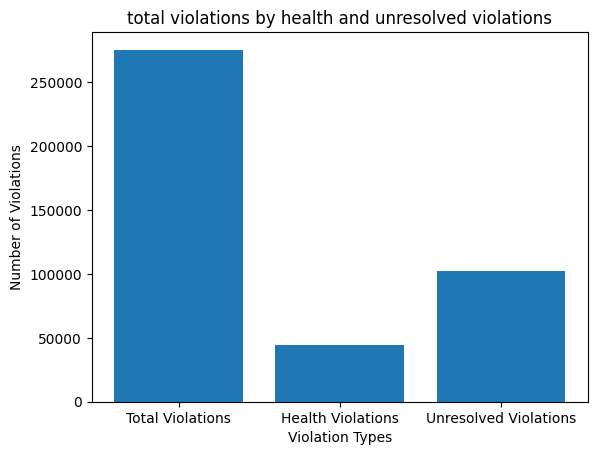

In [63]:
import matplotlib.pyplot as plt

plt.bar(['Total Violations', 'Health Violations', 'Unresolved Violations'], [df['total_violations'].sum(), df['health_violations'].sum(), df['unresolved_violations'].sum()])
plt.title('total violations by health and unresolved violations')
plt.xlabel('Violation Types')
plt.ylabel('Number of Violations')

plt.show()